#  Pergunta 9 - Previsão de risco com Machine Learning

## Modelo temporal de risco de nova defasagem

Este notebook usa dados de um ano para prever se um aluno atualmente sem defasagem entrará em defasagem no ano seguinte.


## Objetivo

Usar os indicadores de um ano para estimar se um aluno que ainda não está defasado entrará em defasagem no ano seguinte.

- **Treino:** dados de 2022 → situação observada em 2023
- **Teste temporal:** dados de 2023 → situação observada em 2024
- **Previsão futura:** dados de 2024 → risco estimado para 2025

## Definição do alvo

- `0`: permaneceu sem defasagem no ano seguinte
- `1`: entrou em defasagem no ano seguinte

O modelo será aplicado somente aos alunos que estavam **sem defasagem no ano atual**.


## 1. Importação das bibliotecas

Nesta etapa carregamos as bibliotecas usadas para:

- manipulação dos dados;
- pré-processamento;
- treinamento dos modelos;
- avaliação;
- geração de gráficos;
- salvamento do modelo.


In [343]:
import warnings
from google.colab import files
from io import BytesIO

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
)

from sklearn.svm import SVC

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEMENTE = 42

## 2. Carregamento da Base Dados (01_Limpeza_Dados)

O notebook procura o arquivo `dados_pede.csv`.


In [317]:
arquivos_enviados = files.upload()

if len(arquivos_enviados) != 1:
    raise ValueError(
        "Envie somente um arquivo CSV."
    )

nome_arquivo = next(
    iter(arquivos_enviados)
)

df = pd.read_csv(
    BytesIO(
        arquivos_enviados[nome_arquivo]
    )
)

print(f"Arquivo carregado: {nome_arquivo}")
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")

Saving dados_pede.csv to dados_pede (9).csv
Arquivo carregado: dados_pede (9).csv
Quantidade de linhas: 3030
Quantidade de colunas: 36


## 3. Validação das colunas necessárias

Antes de continuar, verificamos se todas as colunas exigidas pelo modelo estão presentes.


In [318]:
df_columns = [
    "ra",
    "ano",
    "idade",
    "genero",
    "ano_ingresso",
    "instituicao_padrao",
    "fase_num",
    "iaa",
    "ieg",
    "ips",
    "ida",
    "nota_matematica",
    "nota_portugues",
    "ipv",
    "defasagem",
]

colunas_ausentes = [
    coluna
    for coluna in df_columns
    if coluna not in df.columns
]

if colunas_ausentes:
    raise ValueError(
        f"Estas colunas não foram encontradas: {colunas_ausentes}"
    )

print("Todas as colunas obrigatórias foram encontradas.")


Todas as colunas obrigatórias foram encontradas.


## 4. Conversão das variáveis numéricas

Garantimos que idade, fase, indicadores, notas e defasagem estejam em formato numérico.

Valores inválidos são convertidos para `NaN`.


In [319]:
colunas_numericas_base = [
    "ano",
    "idade",
    "ano_ingresso",
    "fase_num",
    "iaa",
    "ieg",
    "ips",
    "ida",
    "nota_matematica",
    "nota_portugues",
    "ipv",
    "defasagem",
]

for coluna in colunas_numericas_base:
    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce",
    )

df[colunas_numericas_base].dtypes


,0
ano,int64
idade,int64
ano_ingresso,int64
fase_num,int64
iaa,float64
ieg,float64
ips,float64
ida,float64
nota_matematica,float64
nota_portugues,float64


## 5. Criação da variável → **anos_no_programa**

Em vez de usar apenas o ano de ingresso, criamos:

**anos_no_programa = ano analisado - ano de ingresso**

Essa variável indica há quantos anos o aluno está no programa.


In [320]:
df["anos_no_programa"] = (
    df["ano"] - df["ano_ingresso"]
)

# Valores negativos seriam inconsistentes.
df.loc[
    df["anos_no_programa"] < 0,
    "anos_no_programa"
] = np.nan

df[["ano", "ano_ingresso", "anos_no_programa"]].head()


,ano,ano_ingresso,anos_no_programa
0,2022,2016,6.0
1,2022,2017,5.0
2,2022,2016,6.0
3,2022,2017,5.0
4,2022,2016,6.0


## 6. Construção do alvo futuro

Ligamos cada registro do ano atual à defasagem observada no ano seguinte.

Exemplos:

- dados de 2022 → defasagem em 2023
- dados de 2023 → defasagem em 2024


In [321]:
base_futura = df[
    ["ra", "ano", "defasagem"]
].copy()


base_futura["ano"] = base_futura["ano"] - 1

base_futura = base_futura.rename(
    columns={
        "defasagem": "defasagem_proximo_ano"
    }
)

base_modelo = df.merge(
    base_futura,
    on=["ra", "ano"],
    how="inner",
    validate="one_to_one",
)

base_modelo = base_modelo.dropna(
    subset=[
        "defasagem",
        "defasagem_proximo_ano",
    ]
).copy()

print("Dimensão da base temporal:", base_modelo.shape)

display(
    base_modelo[
        [
            "ano",
            "ra",
            "defasagem",
            "defasagem_proximo_ano",
        ]
    ].tail(10)
)


Dimensão da base temporal: (1365, 38)


,ano,ra,defasagem,defasagem_proximo_ano
1355,2023,RA-1270,0,0
1356,2023,RA-29,0,0
1357,2023,RA-17,0,0
1358,2023,RA-21,0,0
1359,2023,RA-25,0,0
1360,2023,RA-2,0,0
1361,2023,RA-1271,0,0
1362,2023,RA-1272,0,0
1363,2023,RA-1273,1,0
1364,2023,RA-1274,0,0


## 7. Seleção da população e criação do alvo

Foram considerados alunos sem defasagem atual e em fases inferiores à Fase 8. As fases finais foram retiradas porque, pela estrutura da variável de defasagem, a entrada em nova defasagem não é comparável aos demais alunos.

O alvo será:

- `0`: continuou sem defasagem;
- `1`: ficou defasado no ano seguinte.


In [322]:
base_modelo = base_modelo[
    (base_modelo["defasagem"] >= 0)
    & (base_modelo["fase_num"] < 8)
].copy()

base_modelo["alvo_novo_risco"] = (
    base_modelo["defasagem_proximo_ano"] < 0
).astype(int)

resumo_target = (
    base_modelo
    .groupby("ano")["alvo_novo_risco"]
    .agg(
        alunos="count",
        novos_casos="sum",
        percentual_novo_risco="mean",
    )
)

resumo_target["percentual_novo_risco"] = (
    resumo_target["percentual_novo_risco"] * 100
).round(2)

display(resumo_target)


,alunos,novos_casos,percentual_novo_risco
ano,,,
2022,189,60,31.75
2023,311,84,27.01


## 8. Variáveis utilizadas pelo modelo

### Numéricas

- idade
- fase atual
- tempo no programa
- IDA
- IEG
- IPV
- IPS
- IAA
- nota de Matemática
- nota de Português

O modelo principal utiliza apenas variáveis numéricas disponíveis no ano atual. Variáveis diretamente relacionadas à construção do alvo, como IAN, fase ideal e defasagem, não são utilizadas como preditoras para reduzir risco de vazamento de informação.

In [323]:
features_numericas = [
    "idade",
    "fase_num",
    "anos_no_programa",
    "ida",
    "ieg",
    "ipv",
    "ips",
    "iaa",
    "nota_matematica",
    "nota_portugues",
]


features_modelo = features_numericas.copy()

target_modelo = "alvo_novo_risco"

print("Features numéricas:", features_numericas)


Features numéricas: ['idade', 'fase_num', 'anos_no_programa', 'ida', 'ieg', 'ipv', 'ips', 'iaa', 'nota_matematica', 'nota_portugues']


## 9. Separação temporal entre treino e teste

Não usamos divisão aleatória.

- **Treino:** registros de 2022 com resultado observado em 2023;
- **Teste:** registros de 2023 com resultado observado em 2024.


In [324]:
treino = base_modelo[
    base_modelo["ano"] == 2022
].copy()

teste = base_modelo[
    base_modelo["ano"] == 2023
].copy()

if treino.empty:
    raise ValueError(
        "Não foram encontrados registros de 2022 para o treino."
    )

if teste.empty:
    raise ValueError(
        "Não foram encontrados registros de 2023 para o teste."
    )

X_treino = treino[features_modelo].copy()
y_treino = treino[target_modelo].copy()

X_teste = teste[features_modelo].copy()
y_teste = teste[target_modelo].copy()

print(
    f"Treino: {len(treino)} alunos | "
    f"{int(y_treino.sum())} novos casos"
)

print(
    f"Teste: {len(teste)} alunos | "
    f"{int(y_teste.sum())} novos casos"
)


Treino: 189 alunos | 60 novos casos
Teste: 311 alunos | 84 novos casos


## 10. Análise dos valores ausentes

Os valores ausentes não são alterados no CSV original. Durante o treinamento, os valores ausentes das features numéricas são preenchidos pela mediana aprendida exclusivamente no conjunto de treino.


In [325]:
ausentes_treino = pd.DataFrame({
    "quantidade": X_treino.isna().sum(),
    "percentual": (
        X_treino.isna().mean() * 100
    ).round(2),
})

ausentes_teste = pd.DataFrame({
    "quantidade": X_teste.isna().sum(),
    "percentual": (
        X_teste.isna().mean() * 100
    ).round(2),
})

print("Ausentes no treino:")
display(ausentes_treino)

print("Ausentes no teste:")
display(ausentes_teste)


Ausentes no treino:


,quantidade,percentual
idade,0,0.0
fase_num,0,0.0
anos_no_programa,0,0.0
ida,0,0.0
ieg,0,0.0
ipv,0,0.0
ips,0,0.0
iaa,0,0.0
nota_matematica,0,0.0
nota_portugues,0,0.0


Ausentes no teste:


,quantidade,percentual
idade,0,0.00
fase_num,0,0.00
anos_no_programa,0,0.00
ida,11,3.54
ieg,11,3.54
ipv,11,3.54
ips,0,0.00
iaa,0,0.00
nota_matematica,11,3.54
nota_portugues,11,3.54


## 11. Pré-processamento

### Variáveis numéricas

O pré-processamento é realizado dentro do pipeline para evitar vazamento de informação. Valores ausentes são preenchidos pela mediana aprendida exclusivamente nos dados utilizados durante o treinamento.

As variáveis são padronizadas com **StandardScaler**, etapa particularmente relevante para modelos sensíveis à escala, como Regressão Logística e SVM. Para os modelos baseados em árvores, como Random Forest e Extra Trees, a padronização não altera a lógica de divisão das árvores.



In [326]:
preprocessador = Pipeline(
    steps=[
        (
            "imputacao",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "padronizacao",
            StandardScaler(),
        ),
    ]
)

print("Pré-processador numérico criado.")


Pré-processador numérico criado.


## 12. Modelos comparados

Foram comparados quatro algoritmos de classificação:

- Regressão Logística
- Random Forest
- Extra Trees
- SVM com kernel RBF

Os modelos foram avaliados utilizando a mesma estratégia de validação cruzada sobre o conjunto de treino. O balanceamento das classes foi utilizado para considerar a menor frequência dos casos positivos de nova defasagem.

In [327]:
modelos = {
    "Regressão Logística": LogisticRegression(
        class_weight="balanced",
        random_state=SEMENTE,
        max_iter=2000,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEMENTE,
        n_jobs=-1,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEMENTE,
        n_jobs=-1,
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=SEMENTE,
    ),
}


pipelines = {}

for nome_modelo, algoritmo in modelos.items():

    pipelines[nome_modelo] = Pipeline(
        steps=[
            (
                "preprocessamento",
                preprocessador,
            ),
            (
                "modelo",
                algoritmo,
            ),
        ]
    )


print("Modelos que serão avaliados:")

for nome in pipelines.keys():
    print("-", nome)

Modelos que serão avaliados:
- Regressão Logística
- Random Forest
- Extra Trees
- SVM RBF


## 13. Validação cruzada dentro do treino

A comparação entre os modelos usa somente os dados de treino.

Métricas avaliadas:

- acurácia
- ROC-AUC
- PR-AUC
- recall
- precisão
- F1-score


In [328]:
quantidade_menor_classe = (
    y_treino.value_counts().min()
)

numero_divisoes = min(
    5,
    int(quantidade_menor_classe),
)

if numero_divisoes < 2:
    raise ValueError(
        "Não há casos suficientes para validação cruzada."
    )

validacao = RepeatedStratifiedKFold(
    n_splits=numero_divisoes,
    n_repeats=10,
    random_state=SEMENTE,
)

metricas = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
}

resultados_comparacao = []

for nome_modelo, pipeline in pipelines.items():

    scores = cross_validate(
        estimator=pipeline,
        X=X_treino,
        y=y_treino,
        cv=validacao,
        scoring=metricas,
        n_jobs=-1,
        error_score="raise",
    )

    resultados_comparacao.append(
        {
            "modelo": nome_modelo,

            "accuracy_cv":
               scores["test_accuracy"].mean(),

            "roc_auc_cv":
                scores["test_roc_auc"].mean(),

            "roc_auc_dp":
                scores["test_roc_auc"].std(),

            "pr_auc_cv":
                scores["test_pr_auc"].mean(),

            "pr_auc_dp":
                scores["test_pr_auc"].std(),

            "recall_cv":
                scores["test_recall"].mean(),

            "precision_cv":
                scores["test_precision"].mean(),

            "f1_cv":
                scores["test_f1"].mean(),
        }
    )

comparacao = (
    pd.DataFrame(resultados_comparacao)
    .sort_values(
        "roc_auc_cv",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(comparacao.round(4))


,modelo,accuracy_cv,roc_auc_cv,roc_auc_dp,pr_auc_cv,pr_auc_dp,recall_cv,precision_cv,f1_cv
0,Extra Trees,0.7285,0.8173,0.0757,0.7073,0.1152,0.7717,0.5589,0.6430
1,Regressão Logística,0.7080,0.8006,0.0702,0.6742,0.1162,0.7133,0.5402,0.6084
2,Random Forest,0.7296,0.7950,0.0788,0.6648,0.1214,0.6633,0.5717,0.6076
3,SVM RBF,0.6550,0.7339,0.0730,0.5664,0.1097,0.7483,0.4792,0.5789


## 14. Seleção e treinamento do melhor modelo

O modelo com maior ROC-AUC médio na validação cruzada será treinado usando todos os registros de 2022.


In [329]:
nome_melhor_modelo = comparacao.loc[
    0,
    "modelo"
]

melhor_modelo = pipelines[
    nome_melhor_modelo
]

print(
    "Modelo selecionado:",
    nome_melhor_modelo
)

melhor_modelo.fit(
    X_treino,
    y_treino,
)

print("Treinamento concluído.")


Modelo selecionado: Extra Trees
Treinamento concluído.


## 15. Previsões no teste temporal

**Escolha do limiar de classificação**

O modelo produz uma probabilidade estimada de risco entre 0 e 1. Para transformar essa probabilidade em uma classificação de risco (0 ou 1), foi definido um limiar operacional utilizando exclusivamente o conjunto de treino.

As probabilidades utilizadas para selecionar o limiar foram obtidas por meio de previsões out-of-fold, evitando o uso do conjunto de teste nessa decisão.

Como o objetivo do projeto é identificar preventivamente alunos com maior risco de entrar em defasagem, foram considerados os limiares capazes de atingir pelo menos **80% de recall** no conjunto de treino.

Entre esses candidatos, foi selecionado o limiar com maior precisão.

O limiar final selecionado foi **0,48**, apresentando recall out-of-fold de **83,33%** e precisão de **57,47%**.


In [330]:
validacao_limiar = StratifiedKFold(
    n_splits=numero_divisoes,
    shuffle=True,
    random_state=SEMENTE,
)

probabilidades_oof = cross_val_predict(
    melhor_modelo,
    X_treino,
    y_treino,
    cv=validacao_limiar,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]


resultados_limiares = []

for limiar in np.linspace(
    0.10,
    0.90,
    81,
):

    previsoes_oof = (
        probabilidades_oof >= limiar
    ).astype(int)

    resultados_limiares.append(
        {
            "limiar": limiar,

            "recall": recall_score(
                y_treino,
                previsoes_oof,
                zero_division=0,
            ),

            "precision": precision_score(
                y_treino,
                previsoes_oof,
                zero_division=0,
            ),

            "f1": f1_score(
                y_treino,
                previsoes_oof,
                zero_division=0,
            ),
        }
    )


tabela_limiares = pd.DataFrame(
    resultados_limiares
)


# Define o recall mínimo desejado
RECALL_MINIMO = 0.80


# Mantém apenas limiares que atingem
# pelo menos 80% de recall no treino
candidatos = tabela_limiares[
    tabela_limiares["recall"] >= RECALL_MINIMO
].copy()


if candidatos.empty:

    raise ValueError(
        "Nenhum limiar atingiu "
        "o recall mínimo definido."
    )


# Entre os limiares que atingem o recall mínimo,
# escolhe aquele com maior precisão
candidatos = (
    candidatos
    .sort_values(
        [
            "precision",
            "f1",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


LIMIAR = float(
    candidatos.loc[
        0,
        "limiar",
    ]
)


print(
    f"Limiar selecionado: {LIMIAR:.2f}"
)

print(
    f"Recall OOF: "
    f"{candidatos.loc[0, 'recall']:.2%}"
)

print(
    f"Precisão OOF: "
    f"{candidatos.loc[0, 'precision']:.2%}"
)


display(
    candidatos
    .head(10)
    .round(4)
)


Limiar selecionado: 0.48
Recall OOF: 83.33%
Precisão OOF: 57.47%


,limiar,recall,precision,f1
0,0.48,0.8333,0.5747,0.6803
1,0.47,0.8333,0.5618,0.6711
2,0.46,0.8500,0.5543,0.6711
3,0.45,0.9000,0.5455,0.6792
4,0.43,0.9000,0.5294,0.6667
5,0.44,0.9000,0.5294,0.6667
6,0.42,0.9167,0.5093,0.6548
7,0.41,0.9333,0.4912,0.6437
8,0.40,0.9333,0.4786,0.6328
9,0.39,0.9333,0.4667,0.6222


## 16. Avaliação no teste temporal

As métricas do teste mostram o desempenho do modelo em um período posterior ao treinamento.


In [331]:
probabilidades_teste = (
    melhor_modelo
    .predict_proba(X_teste)[:, 1]
)

previsoes_teste = (
    probabilidades_teste >= LIMIAR
).astype(int)

print("y_teste:", len(y_teste))
print("X_teste:", len(X_teste))
print("probabilidades_teste:", len(probabilidades_teste))
print("previsoes_teste:", len(previsoes_teste))

y_teste: 311
X_teste: 311
probabilidades_teste: 311
previsoes_teste: 311


In [332]:
acuracia = accuracy_score(
    y_teste,
    previsoes_teste
)

precisao = precision_score(
    y_teste,
    previsoes_teste,
    zero_division=0
)

recall = recall_score(
    y_teste,
    previsoes_teste,
    zero_division=0
)

f1 = f1_score(
    y_teste,
    previsoes_teste,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_teste,
    probabilidades_teste
)

pr_auc = average_precision_score(
    y_teste,
    probabilidades_teste
)

brier = brier_score_loss(
    y_teste,
    probabilidades_teste
)


resultados_teste = pd.DataFrame(
    {
        "Métrica": [
            "Acurácia",
            "Precisão",
            "Recall",
            "F1-score",
            "ROC-AUC",
            "PR-AUC",
            "Brier Score",
        ],

        "Resultado": [
            acuracia,
            precisao,
            recall,
            f1,
            roc_auc,
            pr_auc,
            brier,
        ],
    }
)

display(
    resultados_teste.round(4)
)

,Métrica,Resultado
0,Acurácia,0.7460
1,Precisão,0.5229
2,Recall,0.6786
3,F1-score,0.5907
4,ROC-AUC,0.8460
5,PR-AUC,0.6842
6,Brier Score,0.1570


In [333]:
probabilidade_base = (
    np.repeat(
        y_treino.mean(),
        len(y_teste)
    )
)

brier_base = brier_score_loss(
    y_teste,
    probabilidade_base
)

comparacao_brier = pd.DataFrame(
    {
        "Modelo": [
            "Modelo preditivo",
            "Previsão ingênua"
        ],

        "Brier Score": [
            brier,
            brier_base
        ]
    }
)

display(
    comparacao_brier.round(4)
)

,Modelo,Brier Score
0,Modelo preditivo,0.1570
1,Previsão ingênua,0.1994


### Avaliação das probabilidades — Brier Score

O **Brier Score** avalia a qualidade das probabilidades previstas pelo modelo, calculando a diferença entre a probabilidade estimada e o resultado que realmente ocorreu (0 ou 1). Quanto menor o valor, melhor a qualidade das previsões probabilísticas, sendo **0 o resultado ideal**.

No teste temporal, o modelo apresentou **Brier Score de 0,157**. Como referência, uma estratégia ingênua que atribuísse a todos os alunos a mesma probabilidade de risco, baseada apenas na prevalência histórica, apresentou Brier Score de aproximadamente **0,1994**.

Portanto, as probabilidades produzidas pelo modelo apresentam menor erro do que uma previsão baseada somente na frequência histórica de novos casos de defasagem, indicando que as características individuais dos alunos acrescentam informação relevante para a estimativa de risco.

O Brier Score não deve ser interpretado como uma porcentagem de erro. Um valor de 0,157 não significa que o modelo possui 15,7% de erro.

## Checagem de Overfitting

In [334]:
probabilidades_treino = (
    melhor_modelo
    .predict_proba(X_treino)[:, 1]
)

roc_auc_treino = roc_auc_score(
    y_treino,
    probabilidades_treino,
)

roc_auc_cv = comparacao.loc[
    comparacao["modelo"]
    == nome_melhor_modelo,
    "roc_auc_cv",
].iloc[0]

diagnostico_overfitting = pd.DataFrame(
    {
        "Avaliação": [
            "Treino",
            "Validação cruzada",
            "Teste temporal",
        ],

        "ROC-AUC": [
            roc_auc_treino,
            roc_auc_cv,
            roc_auc,
        ],
    }
)

display(
    diagnostico_overfitting.round(4)
)

,Avaliação,ROC-AUC
0,Treino,0.9326
1,Validação cruzada,0.8173
2,Teste temporal,0.8460


## 17. Gráficos de avaliação

Serão exibidos:

- matriz de confusão
- curva ROC
- curva Precisão × Recall


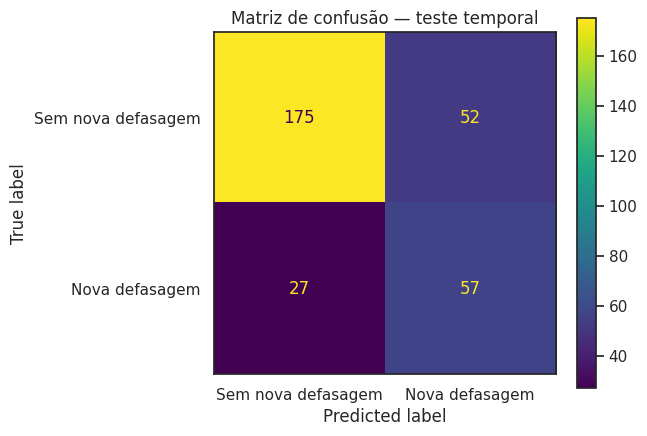

In [335]:
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes_teste,
    display_labels=[
        "Sem nova defasagem",
        "Nova defasagem",
    ],
)

plt.title(
    "Matriz de confusão — teste temporal"
)
plt.tight_layout()
plt.show()


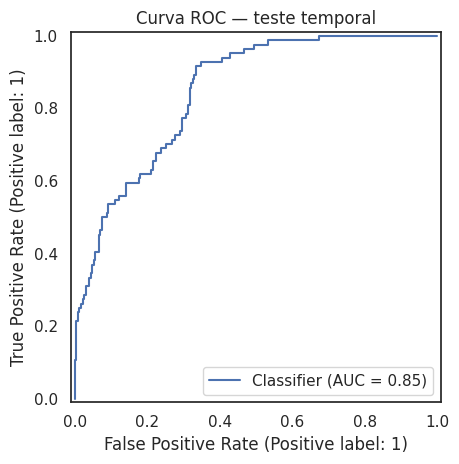

In [336]:
RocCurveDisplay.from_predictions(
    y_teste,
    probabilidades_teste,
)

plt.title(
    "Curva ROC — teste temporal"
)
plt.tight_layout()
plt.show()


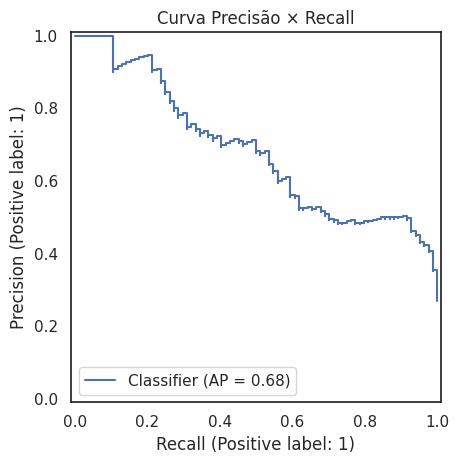

In [337]:
PrecisionRecallDisplay.from_predictions(
    y_teste,
    probabilidades_teste,
)

plt.title(
    "Curva Precisão × Recall"
)
plt.tight_layout()
plt.show()


## 18. Importância das variáveis — Permutation Importance

A importância por permutação mede quanto o ROC-AUC do modelo piora quando os valores de uma variável são embaralhados.

Quanto maior a queda do ROC-AUC, maior a contribuição daquela variável para o desempenho preditivo do modelo.

A análise é utilizada apenas para interpretação do modelo final e não para selecionar novas features com base no conjunto de teste.

In [338]:
resultado_importancia = permutation_importance(
    melhor_modelo,
    X_teste,
    y_teste,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)


importancia_variaveis = pd.DataFrame({
    "variavel": X_teste.columns,
    "queda_media_auc": resultado_importancia.importances_mean,
    "desvio_padrao": resultado_importancia.importances_std
})


importancia_variaveis["queda_media_auc"] = (
    importancia_variaveis["queda_media_auc"] * 100
).round(2)

importancia_variaveis["desvio_padrao"] = (
    importancia_variaveis["desvio_padrao"] * 100
).round(2)


importancia_variaveis = (
    importancia_variaveis
    .sort_values(
        "queda_media_auc",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importancia_variaveis)

,variavel,queda_media_auc,desvio_padrao
0,fase_num,7.12,1.76
1,anos_no_programa,4.66,1.66
2,ipv,3.04,0.63
3,ida,1.08,0.34
4,ips,0.79,0.45
5,nota_portugues,0.46,0.13
6,nota_matematica,0.45,0.35
7,iaa,0.03,0.15
8,ieg,-0.10,0.14
9,idade,-2.82,0.85


### Padrões observados nos indicadores

Para complementar a importância preditiva das variáveis, comparamos as médias dos indicadores no conjunto de treino entre os alunos que permaneceram sem defasagem e aqueles que entraram em defasagem no ano seguinte.

Essa análise é descritiva e não representa relação causal.

In [339]:
indicadores_padrao = [
    "ida",
    "ieg",
    "ipv",
    "ips",
    "iaa",
    "nota_matematica",
    "nota_portugues",
]

padroes_risco = (
    treino
    .groupby("alvo_novo_risco")[
        indicadores_padrao
    ]
    .mean()
    .T
)

padroes_risco.columns = [
    "permaneceu_sem_defasagem",
    "entrou_em_defasagem"
]

padroes_risco["diferenca"] = (
    padroes_risco["entrou_em_defasagem"]
    - padroes_risco["permaneceu_sem_defasagem"]
)

display(
    padroes_risco.round(2)
)

,permaneceu_sem_defasagem,entrou_em_defasagem,diferenca
ida,6.96,6.40,-0.56
ieg,8.58,8.48,-0.10
ipv,7.81,7.15,-0.66
ips,6.85,7.16,0.30
iaa,8.52,8.66,0.13
nota_matematica,6.72,6.02,-0.70
nota_portugues,6.88,6.75,-0.14


Entre os alunos do conjunto de treino que posteriormente entraram em defasagem, observaram-se médias menores principalmente em IPV, IDA e Matemática.

## 19. Treinamento final com todo o histórico disponível

Depois da avaliação honesta no teste temporal, o melhor modelo é treinado novamente com:

- 2022 → 2023
- 2023 → 2024


In [340]:
X_historico = base_modelo[
    features_modelo
].copy()

y_historico = base_modelo[
    target_modelo
].copy()

melhor_modelo.fit(
    X_historico,
    y_historico,
)

print(
    "Modelo final treinado "
    "com todo o histórico."
)

Modelo final treinado com todo o histórico.


## 20. Estimativa de risco para 2025

Usamos os dados de 2024 dos alunos que ainda não estavam defasados para estimar o risco de nova defasagem em 2025.

Como não possuímos os resultados reais de 2025, essas previsões não podem ser avaliadas neste momento.


In [341]:
base_2024 = df[
    (df["ano"] == 2024)
    & (df["defasagem"].notna())
    & (df["defasagem"] >= 0)
    & (df["fase_num"] < 8)
].copy()


X_2024 = base_2024[
    features_modelo
].copy()



probabilidades_2025 = (
    melhor_modelo
    .predict_proba(X_2024)[:, 1]
)


alertas_2025 = (
    probabilidades_2025 >= LIMIAR
).astype(int)


resultado_2025 = base_2024[
    [
        "ra",
        "ano",
        "fase_num",
        "idade",
        "genero",
        "instituicao_padrao",
    ]
].copy()


resultado_2025[
    "ano_previsto"
] = 2025


resultado_2025[
    "probabilidade_novo_risco"
] = probabilidades_2025


resultado_2025[
    "alerta_risco"
] = alertas_2025


resultado_2025[
    "probabilidade_risco_percentual"
] = (
    resultado_2025[
        "probabilidade_novo_risco"
    ] * 100
).round(2)


resultado_2025 = (
    resultado_2025
    .sort_values(
        "probabilidade_novo_risco",
        ascending=False,
    )
    .reset_index(drop=True)
)


resumo_2025 = pd.DataFrame(
    {
        "Métrica": [
            "Alunos avaliados",
            "Alertas de risco",
            "Percentual de alertas",
            "Limiar utilizado",
        ],

        "Resultado": [
            len(resultado_2025),

            int(
                resultado_2025[
                    "alerta_risco"
                ].sum()
            ),

            round(
                resultado_2025[
                    "alerta_risco"
                ].mean() * 100,
                2,
            ),

            LIMIAR,
        ],
    }
)

display(resumo_2025)

,Métrica,Resultado
0,Alunos avaliados,520.00
1,Alertas de risco,178.00
2,Percentual de alertas,34.23
3,Limiar utilizado,0.48


Com base nos padrões aprendidos entre 2022 e 2024, o modelo identificou **178 alertas entre 520 alunos elegíveis** para a estimativa de risco em 2025.

Como os resultados reais de 2025 ainda não estão disponíveis, essas estimativas devem ser utilizadas como instrumento de **priorização preventiva**, e não como previsões determinísticas de que os alunos necessariamente entrarão em defasagem.

## 21. Salvamento do modelo e das previsões futuras

O pipeline completo será salvo, incluindo:

- tratamento dos valores ausentes
- transformação das variáveis
- algoritmo escolhido
- definição das features
- limiar de classificação


In [342]:
artefato_modelo = {
    "pipeline": melhor_modelo,

    "nome_modelo": nome_melhor_modelo,

    "features_modelo": features_modelo,

    "features_numericas": features_numericas,

    "limiar": LIMIAR,

    "definicao_alvo": (
        "Aluno sem defasagem no ano atual "
        "que entra em defasagem no ano seguinte."
    ),

    "populacao_elegivel": (
        "Alunos com defasagem atual >= 0 "
        "e fase_num < 8."
    ),

    "validacao": (
        "Treino 2022->2023 e "
        "teste 2023->2024."
    ),

    "criterio_limiar": (
        "Limiar selecionado no treino a partir de "
        "previsões out-of-fold, exigindo recall mínimo "
        "de 80% e escolhendo, entre os candidatos, "
        "aquele com maior precisão."
    ),
}


joblib.dump(
    artefato_modelo,
    "modelo_risco_nova_defasagem.joblib"
)


resultado_2025.to_csv(
    "previsoes_risco_2025.csv",
    index=False
)


print(
    "Modelo salvo em: "
    "modelo_risco_nova_defasagem.joblib"
)

print(
    "Previsões salvas em: "
    "previsoes_risco_2025.csv"
)

Modelo salvo em: modelo_risco_nova_defasagem.joblib
Previsões salvas em: previsoes_risco_2025.csv


## 22. Interpretação final

O modelo selecionado por meio da validação cruzada foi o **Extra Trees**, com ROC-AUC médio de aproximadamente **0,82** na validação cruzada realizada sobre o conjunto de treino.

Na avaliação temporal, utilizando os dados de 2023 para prever a entrada em defasagem em 2024, o modelo apresentou:

- Acurácia de **74,60%**
- ROC-AUC de **0,846**
- PR-AUC de **0,684**
- recall de **67,86%**
- precisão de **52,29%**
- F1-score de **59,07%**
- Brier Score de **0,157**

Dos 84 alunos que efetivamente entraram em defasagem em 2024, o modelo identificou corretamente **57 alunos** e deixou de identificar **27 alunos**.

Embora o desempenho no conjunto de treino tenha sido superior ao observado na validação cruzada, o ROC-AUC do teste temporal permaneceu próximo ao desempenho de validação, sem indicar perda relevante de capacidade de generalização no período futuro.

A análise por **Permutation Importance** indicou que a fase atual apresentou a maior contribuição para o desempenho preditivo. Entre os indicadores educacionais avaliados, **IPV e IPS** apresentaram maior contribuição para a identificação do risco.

Neste trabalho, a **entrada em risco** foi operacionalizada como a transição de uma situação sem defasagem no ano atual (defasagem >= 0) para uma situação de defasagem no ano seguinte (defasagem < 0).

Dessa forma, o modelo deve ser utilizado como uma ferramenta de **priorização preventiva**, auxiliando na identificação de alunos que podem demandar acompanhamento mais próximo, e não como uma determinação de que determinado aluno necessariamente ficará defasado.

As estimativas para 2025 foram calculadas a partir das características observadas em 2024. Como os resultados reais de 2025 ainda não estão disponíveis, essas estimativas ainda não podem ser validadas e devem ser interpretadas como scores de priorização de risco.

Como limitação, a base possui apenas duas transições anuais disponíveis para construção e avaliação temporal do modelo: **2022→2023** e **2023→2024**. Além disso, o modelo foi desenvolvido especificamente para prever novos casos de defasagem entre alunos atualmente sem defasagem e em fases inferiores à Fase 8.

O limiar de classificação de **0,48** foi selecionado exclusivamente a partir das previsões out-of-fold do conjunto de treino. Foram considerados os limiares capazes de atingir recall mínimo de **80%**, sendo escolhido, entre eles, aquele com maior precisão. O limiar selecionado apresentou recall de **83,33%** e precisão de **57,47%** nas previsões out-of-fold.

A análise por **Permutation Importance** indicou que a fase atual apresentou a maior contribuição para o desempenho preditivo. Entre os indicadores educacionais avaliados, **IPV, IDA e IPS** apresentaram as maiores contribuições para a identificação do risco.